## 2. Simulate a small company

a) Connect python to gemini, very important that you place the api key in .env and gitignore it

b) Use gemini to simulate 20 data points in json format containing the following fields: first_name, last_name, phone_number, email, department, salary, title. See if you can prompt to direct the LLM output to have swedish names, phone numbers in swedish format (+46 731 29 52), departments (IT, HR, marketing, sales), reasonable salary (you might need to check some swedish statistics on salaries) and corresponding titles within these departments.

c) Now use pydantic to validate this json and put in proper schema that the fields should follow. You might need to do some processing such as removing backticks and maybe loading json data into a list with `json.loads()`. Also make sure that only correctly validated data should be stored.

d) Write this json data to a folder called output_data.

e) Use pandas to read the data as dataframe

f) Write a csv file to your output_data

g) Load this data into a staging layer and store this into a table called employees.

h) Use gemini to simulate departments data. There should be same departments as those you had in task b. Also add a description field and a contact person.

i) Add a departments table in your duckdb database under staging layer to store this data.

In [24]:
from dotenv import load_dotenv
from google import genai
import os 

# a) Connect python to gemini, very important that you place the api key in .env and gitignore it
load_dotenv()
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
response = client.models.generate_content(model="gemini-2.5-flash", contents="Explain AI in a few words")

print(response.text)

Here are a few options, choose the one that fits best:

*   **Software mimicking human intelligence.**
*   **Machines that learn and make decisions.**
*   **Computers that think and learn.**


In [25]:

# b) Use gemini to simulate 20 data points in json format containing the following fields: 
# first_name, last_name, phone_number, email, department, salary, title. 
# See if you can prompt to direct the LLM output to: 
# have swedish names, phone numbers in swedish format (+46 731 29 52), 
# departments (IT, HR, marketing, sales), reasonable salary (you might need to check some swedish statistics on salaries) 
# and corresponding titles within these departments.

response = client.models.generate_content(model="gemini-2.5-flash", contents="""Give me 20 data points in json format only, containing: 
                                                first_name, last_name, phone_number, email, department, salary, title. 
                                                Requirements for the data points are: 
                                                swedish names, mobile phone numbers in swedish format, 
departments must only be: IT, HR, marketing, sales. reasonable salary and corresponding titles within these departments.                                
                                                                                """)

print(response.text)

```json
[
  {
    "first_name": "Emma",
    "last_name": "Johansson",
    "phone_number": "+46 70 123 45 67",
    "email": "emma.johansson@example.se",
    "department": "IT",
    "salary": 52000,
    "title": "Software Developer"
  },
  {
    "first_name": "William",
    "last_name": "Andersson",
    "phone_number": "+46 72 345 67 89",
    "email": "william.andersson@example.se",
    "department": "HR",
    "salary": 42000,
    "title": "HR Specialist"
  },
  {
    "first_name": "Olivia",
    "last_name": "Karlsson",
    "phone_number": "+46 73 567 89 01",
    "email": "olivia.karlsson@example.se",
    "department": "Marketing",
    "salary": 45000,
    "title": "Digital Marketing Specialist"
  },
  {
    "first_name": "Hugo",
    "last_name": "Nilsson",
    "phone_number": "+46 76 789 01 23",
    "email": "hugo.nilsson@example.se",
    "department": "Sales",
    "salary": 48000,
    "title": "Account Manager"
  },
  {
    "first_name": "Astrid",
    "last_name": "Eriksson",
    "phon

In [26]:
import json

cleaned = response.text.strip("`json")
data = json.loads(cleaned)
type(data), data 



(list,
 [{'first_name': 'Emma',
   'last_name': 'Johansson',
   'phone_number': '+46 70 123 45 67',
   'email': 'emma.johansson@example.se',
   'department': 'IT',
   'salary': 52000,
   'title': 'Software Developer'},
  {'first_name': 'William',
   'last_name': 'Andersson',
   'phone_number': '+46 72 345 67 89',
   'email': 'william.andersson@example.se',
   'department': 'HR',
   'salary': 42000,
   'title': 'HR Specialist'},
  {'first_name': 'Olivia',
   'last_name': 'Karlsson',
   'phone_number': '+46 73 567 89 01',
   'email': 'olivia.karlsson@example.se',
   'department': 'Marketing',
   'salary': 45000,
   'title': 'Digital Marketing Specialist'},
  {'first_name': 'Hugo',
   'last_name': 'Nilsson',
   'phone_number': '+46 76 789 01 23',
   'email': 'hugo.nilsson@example.se',
   'department': 'Sales',
   'salary': 48000,
   'title': 'Account Manager'},
  {'first_name': 'Astrid',
   'last_name': 'Eriksson',
   'phone_number': '+46 79 901 23 45',
   'email': 'astrid.eriksson@exampl

In [27]:
from pydantic import BaseModel, EmailStr, Field, ValidationError
from typing import Literal
# c) Now use pydantic to validate this json and put in proper schema that the fields should follow. 
# You might need to do some processing such as removing backticks and maybe loading json data into a list with `json.loads()`. 
# Also make sure that only correctly validated data should be stored.
class Employees(BaseModel):
    first_name: str
    last_name: str
    phone_number: str
    email: EmailStr
    department: Literal["IT", "HR", "Marketing", "Sales"]
    salary: int = Field(gt=-1)
    title: str

valid_employees = []
for emp in data:
    try:
        valid_employees.append(Employees.model_validate(emp))
    except ValidationError as err:
        print(err) 
        pass
valid_employees

[Employees(first_name='Emma', last_name='Johansson', phone_number='+46 70 123 45 67', email='emma.johansson@example.se', department='IT', salary=52000, title='Software Developer'),
 Employees(first_name='William', last_name='Andersson', phone_number='+46 72 345 67 89', email='william.andersson@example.se', department='HR', salary=42000, title='HR Specialist'),
 Employees(first_name='Olivia', last_name='Karlsson', phone_number='+46 73 567 89 01', email='olivia.karlsson@example.se', department='Marketing', salary=45000, title='Digital Marketing Specialist'),
 Employees(first_name='Hugo', last_name='Nilsson', phone_number='+46 76 789 01 23', email='hugo.nilsson@example.se', department='Sales', salary=48000, title='Account Manager'),
 Employees(first_name='Astrid', last_name='Eriksson', phone_number='+46 79 901 23 45', email='astrid.eriksson@example.se', department='IT', salary=65000, title='DevOps Engineer'),
 Employees(first_name='Axel', last_name='Larsson', phone_number='+46 70 234 56 7

In [ ]:
### Make the instance into a dictionary
# e) Use pandas to read the data as dataframe
import pandas as pd
employee_dict = [emp.model_dump() for emp in valid_employees]
type(employee_dict), employee_dict
employee_dict[1]["first_name"]
df = pd.DataFrame(employee_dict)
df.head(1)

In [29]:

# d) Write this json data to a folder called output_data.
# data_to_write = [emp.model_dump() for emp in valid_employees]
with open("output_data/employees.json", "w", encoding="utf-8") as file: 
    json.dump(employee_dict, file, indent=2)

# df.to_json("output_data/employees.json", indent=0)

In [34]:

# f) Write a csv file to your output_data
import csv

# with open("output_data/employees.csv", "w", encoding="utf-8") as file: 
#     json.dump(employee_dict, file, indent=2)
# employee_dict är listan med dicts
with open("output_data/employees.csv", "w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=employee_dict[0].keys())
    writer.writeheader()
    writer.writerows(employee_dict)
    
# df.to_csv("employees.json")

In [4]:
df = pd.read_csv("output_data/employees.csv")
df

,first_name,last_name,phone_number,email,department,salary,title
0,Emma,Johansson,+46 70 123 45 67,emma.johansson@example.se,IT,52000,Software Developer
1,William,Andersson,+46 72 345 67 89,william.andersson@example.se,HR,42000,HR Specialist
2,Olivia,Karlsson,+46 73 567 89 01,olivia.karlsson@example.se,Marketing,45000,Digital Marketing Specialist
3,Hugo,Nilsson,+46 76 789 01 23,hugo.nilsson@example.se,Sales,48000,Account Manager
4,Astrid,Eriksson,+46 79 901 23 45,astrid.eriksson@example.se,IT,65000,DevOps Engineer
5,Axel,Larsson,+46 70 234 56 78,axel.larsson@example.se,HR,58000,Talent Acquisition Specialist
6,Elsa,Olsson,+46 72 456 78 90,elsa.olsson@example.se,Marketing,38000,Marketing Coordinator
7,Lucas,Persson,+46 73 678 90 12,lucas.persson@example.se,Sales,62000,Sales Manager
8,Freja,Svensson,+46 76 890 12 34,freja.svensson@example.se,IT,38000,IT Support Specialist
9,Oscar,Gustavsson,+46 79 012 34 56,oscar.gustavsson@example.se,HR,68000,HR Manager


In [37]:
# g) Load this data into a staging layer and store this into a table called employees.

import duckdb
conn = duckdb.connect("employee.duckdb")
# df
# conn.execute("CREATE DATABASE")
conn.execute("CREATE SCHEMA IF NOT EXISTS staging")
conn.execute("CREATE OR REPLACE TABLE staging.employee AS SELECT * FROM df")

df = conn.execute("SELECT * from staging.employee").df()
conn.close()

In [38]:
df.head(1), df["department"].unique()

(  first_name  last_name      phone_number                      email  \
 0       Emma  Johansson  +46 70 123 45 67  emma.johansson@example.se   
 
   department  salary               title  
 0         IT   52000  Software Developer  ,
 array(['IT', 'HR', 'Marketing', 'Sales'], dtype=object))

<Axes: xlabel='last_name', ylabel='salary'>

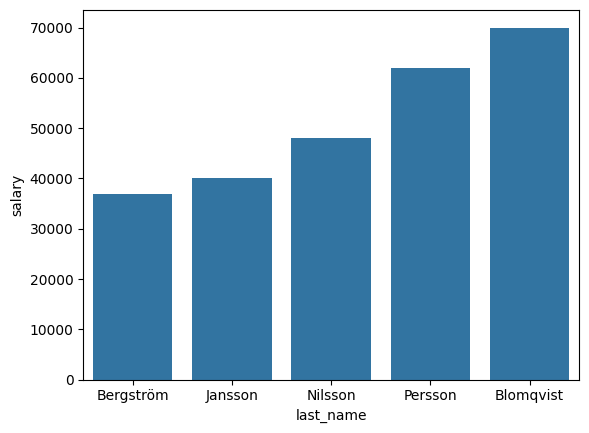

In [ ]:
import seaborn as sns

sns.barplot(df[df["department"] == "Sales"].sort_values(by="salary"), x="last_name", y="salary")
# IT Lundberg/Eriksson
# HR Gustavsson/Larson
# Marketing Ekberg/Pettersson
# Sales Blomqvist/Persson


In [88]:
conn = duckdb.connect("employee.duckdb")
# conn.execute("SELECT * FROM staging.employee where title LIKE '% Manager'").df()
conn.close()

df_managers = duckdb.query("SELECT * FROM df where title LIKE '% Manager'").df()
manager_names = df_managers[["first_name", "last_name", "department"]]
# manager_names = df_managers["first_name"] + " " + df_managers["last_name"]
manager_names

,first_name,last_name,department
0,Hugo,Nilsson,Sales
1,Lucas,Persson,Sales
2,Oscar,Gustavsson,HR
3,Alice,Pettersson,Marketing
4,Nova,Lundberg,IT
5,Maja,Ekberg,Marketing
6,Noah,Blomqvist,Sales


In [89]:
# h) Use gemini to simulate departments data. There should be same departments as those you had in task b. Also add a description field and a contact person.
from dotenv import load_dotenv
from google import genai
import os 

# a) Connect python to gemini, very important that you place the api key in .env and gitignore it
load_dotenv()
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
response = client.models.generate_content(model="gemini-2.5-flash", contents=f"""Give me data points in json format only, containing: 
                                                                            department, description, contact_person (only name)
                                                                            Only valid departments is: IT,HR,Marketing,Sales
                                                                            Only valid contact persons is: {manager_names}
                                                                            """)
print(response.text)

```json
[
  {
    "department": "IT",
    "description": "Manages the company's technology infrastructure, provides technical support, and develops software solutions.",
    "contact_person": "Nova Lundberg"
  },
  {
    "department": "HR",
    "description": "Handles recruitment, employee relations, payroll, and benefits administration.",
    "contact_person": "Oscar Gustavsson"
  },
  {
    "department": "Marketing",
    "description": "Develops and executes strategies to promote products or services, including advertising, public relations, and content creation.",
    "contact_person": "Alice Pettersson"
  },
  {
    "department": "Sales",
    "description": "Responsible for selling products or services, managing client accounts, and achieving revenue targets.",
    "contact_person": "Hugo Nilsson"
  },
  {
    "department": "Marketing",
    "description": "Focuses on market research, brand management, and digital marketing campaigns.",
    "contact_person": "Maja Ekberg"
  },
  {
 

In [142]:
import json
output = response.text
output = output.strip("`json")
department_list = json.loads(output)
test = department_list[0]
test

{'department': 'IT',
 'description': "Manages the company's technology infrastructure, provides technical support, and develops software solutions.",
 'contact_person': 'Nova Lundberg'}

In [143]:
from pydantic import BaseModel, ValidationError
from typing import Literal
class Department(BaseModel): 
    department: Literal["IT", "HR", "Marketing", "Sales"]
    description: str
    contact_person: str # Literal[]

valid_department = []
for d in department_list:
    try:
        valid_department.append(Department.model_validate(d))
    except ValidationError as err: 
        print(err)

In [144]:
valid_department, len(valid_department)

([Department(department='IT', description="Manages the company's technology infrastructure, provides technical support, and develops software solutions.", contact_person='Nova Lundberg'),
  Department(department='HR', description='Handles recruitment, employee relations, payroll, and benefits administration.', contact_person='Oscar Gustavsson'),
  Department(department='Marketing', description='Develops and executes strategies to promote products or services, including advertising, public relations, and content creation.', contact_person='Alice Pettersson'),
  Department(department='Sales', description='Responsible for selling products or services, managing client accounts, and achieving revenue targets.', contact_person='Hugo Nilsson'),
  Department(department='Marketing', description='Focuses on market research, brand management, and digital marketing campaigns.', contact_person='Maja Ekberg'),
  Department(department='Sales', description='Manages lead generation, customer relationsh

In [145]:
import pandas as pd
department_dict = [dep.model_dump() for dep in valid_department]
type(department_dict), department_dict
df_department = pd.DataFrame(department_dict)
df_department

,department,description,contact_person
0,IT,Manages the company's technology infrastructur...,Nova Lundberg
1,HR,"Handles recruitment, employee relations, payro...",Oscar Gustavsson
2,Marketing,Develops and executes strategies to promote pr...,Alice Pettersson
3,Sales,"Responsible for selling products or services, ...",Hugo Nilsson
4,Marketing,"Focuses on market research, brand management, ...",Maja Ekberg
5,Sales,"Manages lead generation, customer relationship...",Lucas Persson
6,Sales,Develops new business opportunities and mainta...,Noah Blomqvist


In [ ]:

# i) Add a departments table in your duckdb database under staging layer to store this data.

conn = duckdb.connect("employee.duckdb")
conn.execute("CREATE or replace table staging.managers AS SELECT * from df_department")
managers = conn.execute("SELECT * FROM staging.managers").df()
employee = conn.execute("SELECT * FROM staging.employee").df()
employee
conn.close()


,first_name,last_name,phone_number,email,department,salary,title
0,Emma,Johansson,+46 70 123 45 67,emma.johansson@example.se,IT,52000,Software Developer
1,William,Andersson,+46 72 345 67 89,william.andersson@example.se,HR,42000,HR Specialist
2,Olivia,Karlsson,+46 73 567 89 01,olivia.karlsson@example.se,Marketing,45000,Digital Marketing Specialist
3,Hugo,Nilsson,+46 76 789 01 23,hugo.nilsson@example.se,Sales,48000,Account Manager
4,Astrid,Eriksson,+46 79 901 23 45,astrid.eriksson@example.se,IT,65000,DevOps Engineer
5,Axel,Larsson,+46 70 234 56 78,axel.larsson@example.se,HR,58000,Talent Acquisition Specialist
6,Elsa,Olsson,+46 72 456 78 90,elsa.olsson@example.se,Marketing,38000,Marketing Coordinator
7,Lucas,Persson,+46 73 678 90 12,lucas.persson@example.se,Sales,62000,Sales Manager
8,Freja,Svensson,+46 76 890 12 34,freja.svensson@example.se,IT,38000,IT Support Specialist
9,Oscar,Gustavsson,+46 79 012 34 56,oscar.gustavsson@example.se,HR,68000,HR Manager


In [164]:
conn.close()
df_managers

,first_name,last_name,phone_number,email,department,salary,title
0,Hugo,Nilsson,+46 76 789 01 23,hugo.nilsson@example.se,Sales,48000,Account Manager
1,Lucas,Persson,+46 73 678 90 12,lucas.persson@example.se,Sales,62000,Sales Manager
2,Oscar,Gustavsson,+46 79 012 34 56,oscar.gustavsson@example.se,HR,68000,HR Manager
3,Alice,Pettersson,+46 70 345 67 89,alice.pettersson@example.se,Marketing,58000,Marketing Manager
4,Nova,Lundberg,+46 72 678 90 12,nova.lundberg@example.se,IT,75000,IT Manager
5,Maja,Ekberg,+46 76 012 34 56,maja.ekberg@example.se,Marketing,50000,Brand Manager
6,Noah,Blomqvist,+46 79 234 56 78,noah.blomqvist@example.se,Sales,70000,Account Manager


In [175]:
dep = df_managers["first_name"] + " " + df_managers["last_name"]
dep.sort_values()

3    Alice Pettersson
0        Hugo Nilsson
1       Lucas Persson
5         Maja Ekberg
6      Noah Blomqvist
4       Nova Lundberg
2    Oscar Gustavsson
dtype: object

In [184]:
df_department["contact_person"].sort_values()
# df_department

2    Alice Pettersson
3        Hugo Nilsson
5       Lucas Persson
4         Maja Ekberg
6      Noah Blomqvist
0       Nova Lundberg
1    Oscar Gustavsson
Name: contact_person, dtype: object